In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

# **STEP-1 :** SELECT REAL WORLD DATASET

In [3]:
from google.colab import files
uploaded = files.upload()

Saving us_elections.csv to us_elections (1).csv


# **STEP-2 :** PERFORM DATA PREPARATION & CLEANING

In [4]:
us_elections_df = pd.read_csv('us_elections.csv')

In [5]:
us_elections_df

,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party_detailed,writein,candidatevotes,totalvotes,version,notes,party_simplified
0,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"CARTER, JIMMY",DEMOCRAT,False,659170,1182850,20210113,NaN,DEMOCRAT
1,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"FORD, GERALD",REPUBLICAN,False,504070,1182850,20210113,NaN,REPUBLICAN
2,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"MADDOX, LESTER",AMERICAN INDEPENDENT PARTY,False,9198,1182850,20210113,NaN,OTHER
3,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"BUBAR, BENJAMIN """"BEN""""",PROHIBITION,False,6669,1182850,20210113,NaN,OTHER
4,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"HALL, GUS",COMMUNIST PARTY USE,False,1954,1182850,20210113,NaN,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4282,2020,WYOMING,WY,56,83,68,US PRESIDENT,"JORGENSEN, JO",LIBERTARIAN,False,5768,278503,20210113,NaN,LIBERTARIAN
4283,2020,WYOMING,WY,56,83,68,US PRESIDENT,"PIERCE, BROCK",INDEPENDENT,False,2208,278503,20210113,NaN,OTHER
4284,2020,WYOMING,WY,56,83,68,US PRESIDENT,NaN,NaN,True,1739,278503,20210113,NaN,OTHER
4285,2020,WYOMING,WY,56,83,68,US PRESIDENT,OVERVOTES,NaN,False,279,278503,20210113,NaN,OTHER


In [6]:
us_elections_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4287 entries, 0 to 4286
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              4287 non-null   int64  
 1   state             4287 non-null   object 
 2   state_po          4287 non-null   object 
 3   state_fips        4287 non-null   int64  
 4   state_cen         4287 non-null   int64  
 5   state_ic          4287 non-null   int64  
 6   office            4287 non-null   object 
 7   candidate         4000 non-null   object 
 8   party_detailed    3831 non-null   object 
 9   writein           4284 non-null   object 
 10  candidatevotes    4287 non-null   int64  
 11  totalvotes        4287 non-null   int64  
 12  version           4287 non-null   int64  
 13  notes             0 non-null      float64
 14  party_simplified  4287 non-null   object 
dtypes: float64(1), int64(7), object(7)
memory usage: 502.5+ KB


In [7]:
us_elections_df.columns

Index(['year', 'state', 'state_po', 'state_fips', 'state_cen', 'state_ic',
       'office', 'candidate', 'party_detailed', 'writein', 'candidatevotes',
       'totalvotes', 'version', 'notes', 'party_simplified'],
      dtype='object')

In [8]:
us_elections_df.shape      #(Rows,Columns)

(4287, 15)

In [9]:
#Looking for missing values in columns
missing_values = us_elections_df.isnull().sum()
print(missing_values);

year                   0
state                  0
state_po               0
state_fips             0
state_cen              0
state_ic               0
office                 0
candidate            287
party_detailed       456
writein                3
candidatevotes         0
totalvotes             0
version                0
notes               4287
party_simplified       0
dtype: int64


In [10]:
#Handle missing values in 'writein' by filling with False (assuming non-entry means not a write-in)

us_elections_df['writein'] = us_elections_df['writein'].fillna(True);

/tmp/ipykernel_5093/857178164.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  us_elections_df['writein'] = us_elections_df['writein'].fillna(True);


In [11]:
#Removing the rows having the null values within the 'candidate' and 'party_detailed' columns
us_elections_df = us_elections_df.dropna(subset=['candidate', 'party_detailed']);

In [12]:
#Verifying that there is no missinf value left in the columns
us_elections_df.isnull().sum()[us_elections_df.isnull().sum() > 0]

,0
notes,3754


In [13]:
#Droping the 'notes' column as it is completely null
us_elections_df = us_elections_df.drop('notes',axis=1)

In [14]:
updated_values = us_elections_df.isnull().sum()

In [15]:
updated_values

,0
year,0
state,0
state_po,0
state_fips,0
state_cen,0
state_ic,0
office,0
candidate,0
party_detailed,0
writein,0


In [16]:
#Rows and columns after cleaning
us_elections_df.shape

(3754, 14)

# **STEP-3 :** PERFORM EXPLORATORY ANALYSIS AND VISUALIZATION

In [17]:
#Statics
us_elections_df.describe()

,year,state_fips,state_cen,state_ic,candidatevotes,totalvotes,version
count,3754.000000,3754.000000,3754.000000,3754.000000,3.754000e+03,3.754000e+03,3754.0
mean,1998.329249,28.634523,54.424081,40.296484,3.549462e+05,2.327842e+06,20210113.0
std,14.124726,15.612621,25.897155,22.597894,8.080805e+05,2.444008e+06,0.0
min,1976.000000,1.000000,11.000000,1.000000,1.000000e+00,1.235740e+05,20210113.0
25%,1984.000000,16.000000,34.000000,23.000000,1.602000e+03,6.481240e+05,20210113.0
50%,2000.000000,28.000000,54.000000,42.000000,1.084350e+04,1.555534e+06,20210113.0
75%,2012.000000,41.000000,82.000000,61.000000,2.923630e+05,2.983417e+06,20210113.0
max,2020.000000,56.000000,95.000000,82.000000,1.111025e+07,1.750088e+07,20210113.0


###Total Votes in US Presidential Elections Over the Years

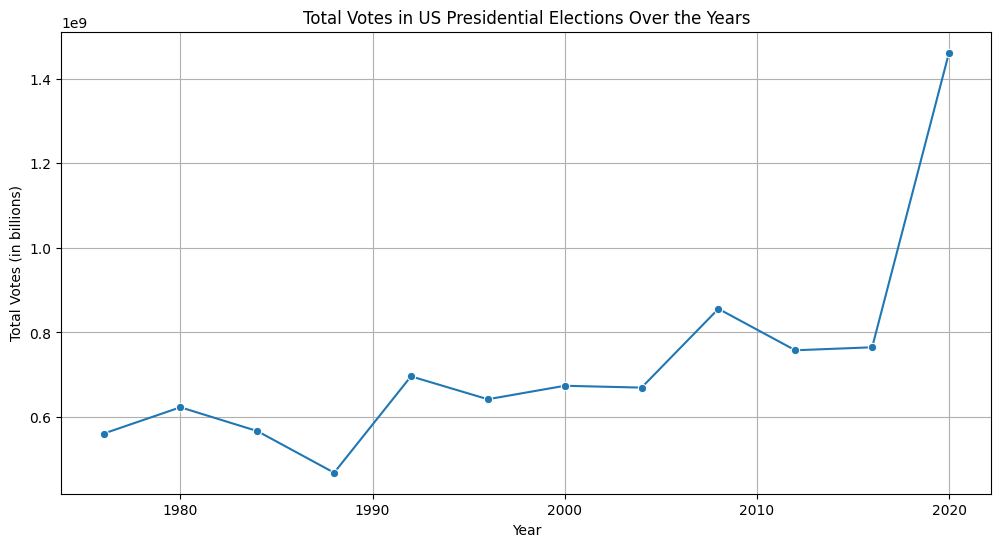

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

votes_by_year = us_elections_df.groupby('year')['totalvotes'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=votes_by_year, x='year', y='totalvotes', marker='o')
plt.title('Total Votes in US Presidential Elections Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Votes (in billions)')
plt.grid(True)
plt.show()

###Total Candidate Votes by Party in US Presidential Elections Over the Years

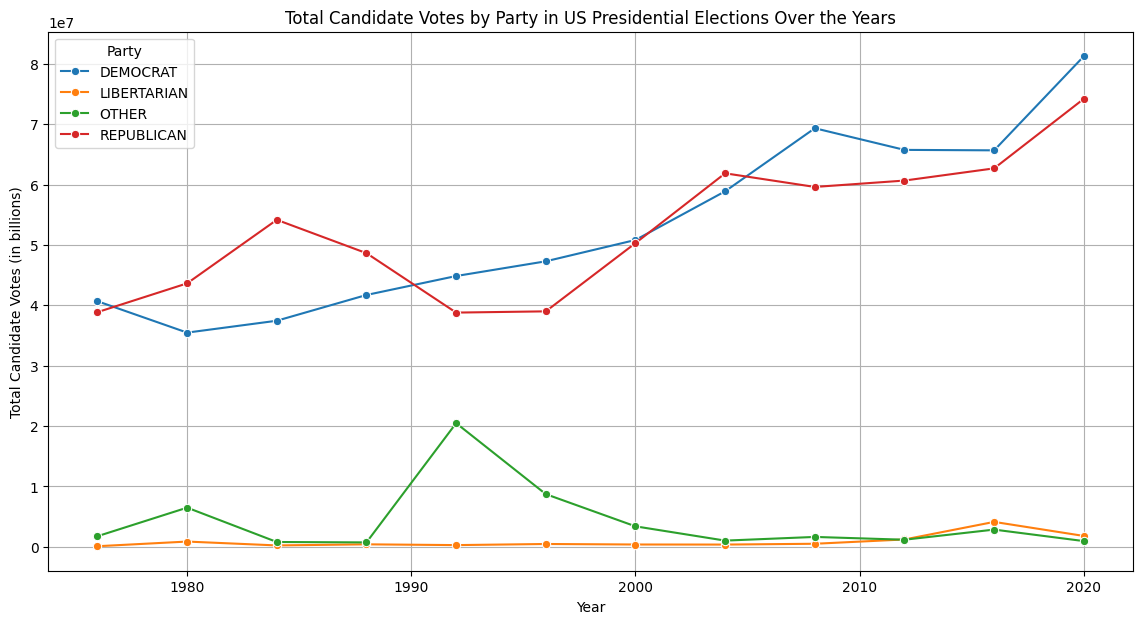

In [19]:
votes_by_party_year = us_elections_df.groupby(['year', 'party_simplified'])['candidatevotes'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=votes_by_party_year, x='year', y='candidatevotes', hue='party_simplified', marker='o')
plt.title('Total Candidate Votes by Party in US Presidential Elections Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Candidate Votes (in billions)')
plt.grid(True)
plt.legend(title='Party')
plt.show()

# **STEP-4 :** QUESTIONS

### Question 1: What are the top 5 states with the highest total votes across all years?

Top 5 states with the highest total votes (all years combined):
state
CALIFORNIA    923035719
NEW YORK      845861048
FLORIDA       593859964
ILLINOIS      391572330
TEXAS         384576040
Name: totalvotes, dtype: int64


/tmp/ipykernel_5093/1217470389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_states.index, y=top_5_states.values, palette='viridis')


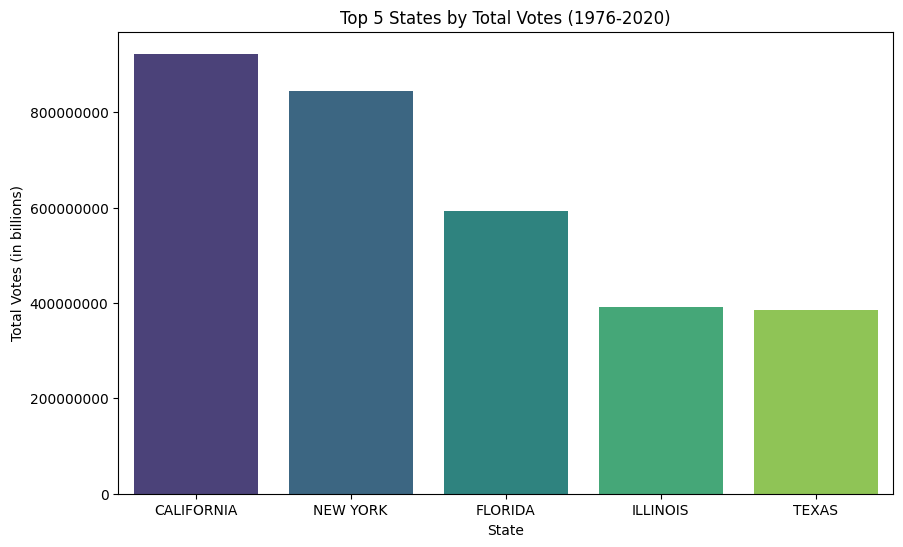

In [20]:
top_5_states = us_elections_df.groupby('state')['totalvotes'].sum().sort_values(ascending=False).head(5)

print("Top 5 states with the highest total votes (all years combined):")
print(top_5_states)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_states.index, y=top_5_states.values, palette='viridis')
plt.title('Top 5 States by Total Votes (1976-2020)')
plt.xlabel('State')
plt.ylabel('Total Votes (in billions)')
plt.ticklabel_format(style='plain', axis='y') # Display full numbers on y-axis
plt.show();

### Question 2: What is the overall distribution of votes by simplified party across all presidential elections in the dataset?

Overall Distribution of Votes by Party (%):
party_simplified
DEMOCRAT       47.974299
REPUBLICAN     47.468495
OTHER           3.751363
LIBERTARIAN     0.805843
Name: candidatevotes, dtype: float64


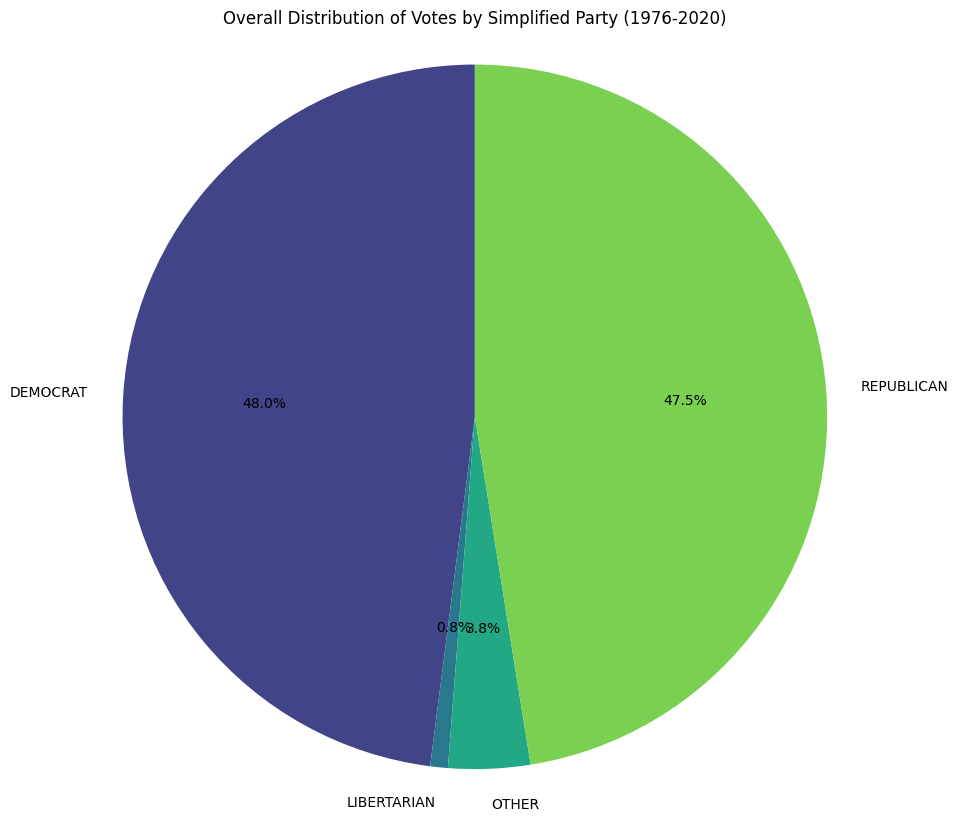

In [21]:
party_vote_distribution = us_elections_df.groupby('party_simplified')['candidatevotes'].sum()

total_all_votes = party_vote_distribution.sum()
party_vote_percentage = (party_vote_distribution / total_all_votes) * 100

print("Overall Distribution of Votes by Party (%):")
print(party_vote_percentage.sort_values(ascending=False))

plt.figure(figsize=(10, 10))
plt.pie(party_vote_percentage, labels=party_vote_percentage.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(party_vote_percentage)))
plt.title('Overall Distribution of Votes by Simplified Party (1976-2020)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Question 3: How has the voter turnout (total votes) changed over the years as a percentage of the US population?

Voter Turnout Percentage Over the Years:
    year  totalvotes  population  turnout_percentage
0   1976   560476250   218000000          257.099197
1   1980   622835449   226000000          275.590907
2   1984   566532584   236000000          240.056180
3   1988   467962533   245000000          191.005116
4   1992   695992170   256000000          271.871941
5   1996   641811354   265000000          242.192964
6   2000   673691141   282000000          238.897568
7   2004   669376461   293000000          228.456130
8   2008   855782971   304000000          281.507556
9   2012   757722460   314000000          241.312885
10  2016   764764758   323000000          236.769275
11  2020  1461771417   331000000          441.622785


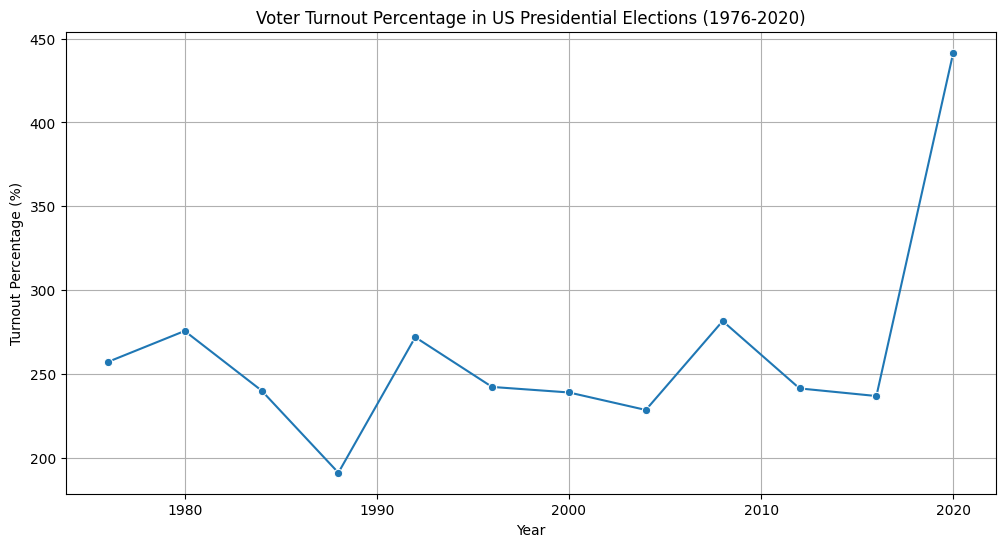

In [22]:
us_population = {
    'year': [1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020],
    'population_millions': [218, 226, 236, 245, 256, 265, 282, 293, 304, 314, 323, 331]
}
population_df = pd.DataFrame(us_population)

# Convert population to actual numbers (from millions to full count)
population_df['population'] = population_df['population_millions'] * 1_000_000

# Merge total votes by year with population data
voter_turnout_df = pd.merge(votes_by_year, population_df, on='year', how='left')

# Calculate voter percentage
voter_turnout_df['turnout_percentage'] = (voter_turnout_df['totalvotes'] / voter_turnout_df['population']) * 100

print("Voter Turnout Percentage Over the Years:")
print(voter_turnout_df[['year', 'totalvotes', 'population', 'turnout_percentage']])

plt.figure(figsize=(12, 6))
sns.lineplot(data=voter_turnout_df, x='year', y='turnout_percentage', marker='o')
plt.title('Voter Turnout Percentage in US Presidential Elections (1976-2020)')
plt.xlabel('Year')
plt.ylabel('Turnout Percentage (%)')
plt.grid(True)
plt.show()

### Question 4: How has the vote share for each major party changed over the years?

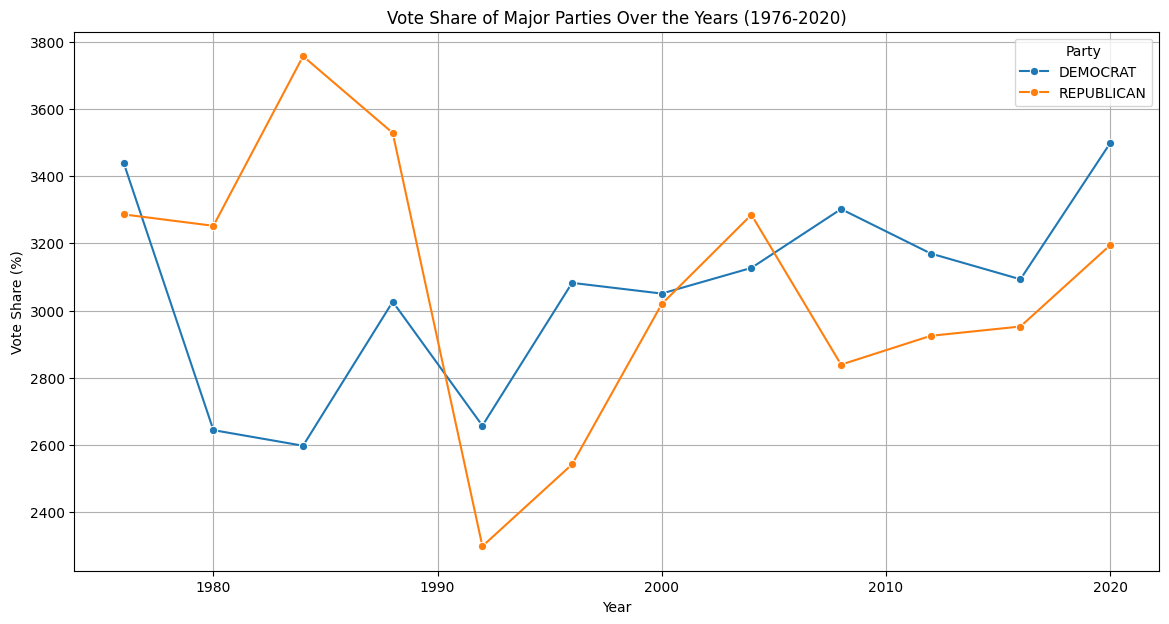

In [23]:
# Calculate total votes for each party per year
party_votes_yearly = us_elections_df.groupby(['year', 'party_simplified'])['candidatevotes'].sum().reset_index()

# Calculate total votes for each year
total_votes_yearly = us_elections_df.groupby('year')['totalvotes'].first().reset_index()

# Merge party votes with total votes to calculate vote share
party_vote_share = pd.merge(party_votes_yearly, total_votes_yearly, on='year', how='left')
party_vote_share['vote_share'] = (party_vote_share['candidatevotes'] / party_vote_share['totalvotes']) * 100

major_parties = ['DEMOCRAT', 'REPUBLICAN']
major_party_vote_share = party_vote_share[party_vote_share['party_simplified'].isin(major_parties)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=major_party_vote_share, x='year', y='vote_share', hue='party_simplified', marker='o')
plt.title('Vote Share of Major Parties Over the Years (1976-2020)')
plt.xlabel('Year')
plt.ylabel('Vote Share (%)')
plt.grid(True)
plt.legend(title='Party')
plt.show()

### Question 5: Which states have consistently high or low voter turnout percentages across all elections?

Top 10 States by Average Voter Turnout Percentage (as % of National Population):
state
CALIFORNIA        4.165767
NEW YORK          2.614916
TEXAS             2.425088
FLORIDA           2.259280
PENNSYLVANIA      1.931565
ILLINOIS          1.856211
OHIO              1.823559
MICHIGAN          1.591624
NEW JERSEY        1.263565
NORTH CAROLINA    1.130995
Name: state_turnout_percentage, dtype: float64

Bottom 10 States by Average Voter Turnout Percentage (as % of National Population):
state
RHODE ISLAND            0.160603
MONTANA                 0.157358
HAWAII                  0.142762
SOUTH DAKOTA            0.127278
DELAWARE                0.119860
NORTH DAKOTA            0.114556
VERMONT                 0.101052
ALASKA                  0.092234
DISTRICT OF COLUMBIA    0.084392
WYOMING                 0.078911
Name: state_turnout_percentage, dtype: float64


/tmp/ipykernel_5093/164759050.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_state_turnout.head(10).index, y=average_state_turnout.head(10).values, palette='coolwarm')


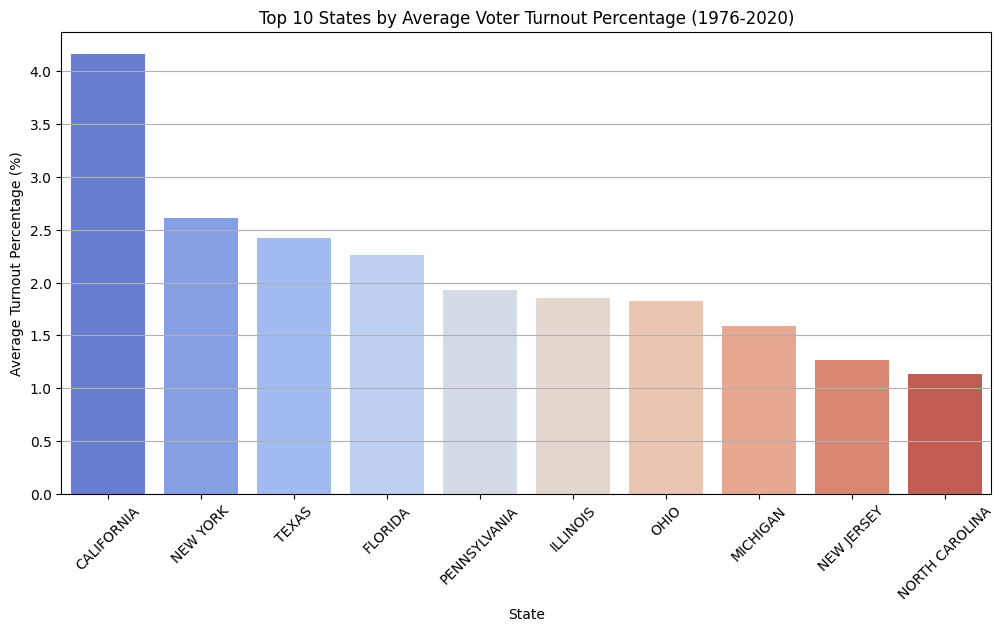

In [24]:
# Calculate total votes and total population per state per year
state_yearly_votes = us_elections_df.groupby(['year', 'state'])['totalvotes'].first().reset_index()

state_turnout_df = pd.merge(state_yearly_votes, population_df[['year', 'population']], on='year', how='left')

# Calculate state-level turnout percentage (as a ratio of state total votes to national population)
state_turnout_df['state_turnout_percentage'] = (state_turnout_df['totalvotes'] / state_turnout_df['population']) * 100

# Calculate the average turnout percentage for each state across all years
average_state_turnout = state_turnout_df.groupby('state')['state_turnout_percentage'].mean().sort_values(ascending=False)

print("Top 10 States by Average Voter Turnout Percentage (as % of National Population):")
print(average_state_turnout.head(10))

print("\nBottom 10 States by Average Voter Turnout Percentage (as % of National Population):")
print(average_state_turnout.tail(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=average_state_turnout.head(10).index, y=average_state_turnout.head(10).values, palette='coolwarm')
plt.title('Top 10 States by Average Voter Turnout Percentage (1976-2020)')
plt.xlabel('State')
plt.ylabel('Average Turnout Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show();

# **STEP-4 :** SUMMARY

## Summary and Future Work

### Key Inferences and Insights:

Our analysis of US Presidential Election data from 1976 to 2020 revealed several interesting trends and patterns:

1.  **Increasing Total Votes**: The `Total Votes in US Presidential Elections Over the Years` graph (after Question 1) clearly shows a general upward trend in the absolute number of votes cast in presidential elections, with a notable surge in 2020.
2.  **Two-Party Dominance**: The `Total Candidate Votes by Party in US Presidential Elections Over the Years` plot (after Question 2) and the `Overall Distribution of Votes by Simplified Party` pie chart (after Question 3) consistently demonstrate the strong dominance of the Democratic and Republican parties. While other parties exist, their collective vote share remains significantly smaller.
3.  **Dynamic Party Vote Share**: The `Vote Share of Major Parties Over the Years` chart (from Question 4) illustrates the fluctuating nature of vote shares between the Democratic and Republican parties. While both generally maintain similar levels, there are noticeable shifts in specific election years, indicating competitive political landscapes.
4.  **Evolving Voter Turnout**: The `Voter Turnout Percentage in US Presidential Elections (1976-2020)` plot (from Question 3) shows that voter turnout, as a percentage of the US population, has varied, with a significant increase in recent years, especially in 2020. It's important to note the simplification used (national population as a proxy) in the state-level turnout calculation.
5.  **State-Level Turnout Disparities**: From Question 5, we identified `Top 10 States by Average Voter Turnout Percentage` (as a percentage of National Population). States like California and New York consistently show high total votes, which when crudely normalized by national population, appear to have higher 'turnout percentages' in this context, reflecting their large populations and voter bases. Conversely, smaller states or those with lower participation rates appear at the bottom.

### Ideas for Future Work:

To further deepen our understanding of US presidential elections, here are some suggestions for future analysis:

1.  **State-Specific Turnout with Local Population Data**: Refine the voter turnout analysis (Question 5) by incorporating actual **state-level population data** for each election year. This would provide a more accurate measure of turnout within each state and allow for more meaningful comparisons.
2.  **Impact of Third Parties**: While we simplified parties into 'DEMOCRAT', 'REPUBLICAN', and 'OTHER', a deeper dive into specific significant third-party candidates and their impact on election outcomes could be insightful.
3.  **Correlation with Socioeconomic Factors**: Merge this dataset with **socioeconomic data** (e.g., income levels, education, unemployment rates) at the state level to explore potential correlations between these factors and voting patterns/turnout.
4.  **Election Volatility/Swing States Analysis**: Identify 'swing states' by analyzing year-over-year changes in party vote share and the margin of victory. This could involve calculating metrics of volatility.
5.  **Candidate-Level Analysis**: Explore the performance of individual candidates across different states and years, potentially looking at factors like incumbency effect or regional popularity.
6.  **Sentiment Analysis**: If available, incorporate **news sentiment data or social media data** related to candidates and elections to see if public sentiment correlates with voting outcomes.

### Resources Found Useful:

*   **US Census Bureau**: For historical population data.
*   **Kaggle Datasets**: As a source for election data and other related public datasets.
*   **Pandas Documentation**: For data manipulation and aggregation techniques.
*   **Matplotlib and Seaborn Documentation**: For advanced visualization customization.
